<a href="https://colab.research.google.com/github/KudjoJedidiah/beginner_projects/blob/main/Fraud_Detection_in_Electricity_and_Gas_Consumption_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

In [ ]:
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
%cd "/content/drive/MyDrive/Zindi/Fraud"

/content/drive/MyDrive/Zindi/Fraud


In [ ]:
import pandas as pd
import os

In [ ]:
client_test=pd.read_csv("/content/drive/MyDrive/Zindi/Fraud/test/client_test.csv",low_memory=False)
client_train=pd.read_csv("/content/drive/MyDrive/Zindi/Fraud/train/client_train.csv",low_memory=False)

invoice_test=pd.read_csv("/content/drive/MyDrive/Zindi/Fraud/test/invoice_test.csv",low_memory=False)
invoice_train=pd.read_csv("/content/drive/MyDrive/Zindi/Fraud/train/invoice_train.csv",low_memory=False)


In [ ]:
print(f"Client_test shape:",{client_test.shape})
print(f"Client_train shape:",client_train.shape)
print(f"invoice_test shape:",invoice_test.shape)
print(f"Invoice_train shape:",invoice_train.shape)

Client_test shape: {(58069, 5)}
Client_train shape: (135493, 6)
invoice_test shape: (1939730, 16)
Invoice_train shape: (4476749, 16)


In [ ]:
invoice_train.head(20)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC
5,train_Client_0,2017-07-17,11,1335667,0,207,9,1,314,0,0,0,15638,15952,8,ELEC
6,train_Client_0,2018-12-07,11,1335667,0,207,9,1,541,0,0,0,15952,16493,12,ELEC
7,train_Client_0,2019-03-19,11,1335667,0,207,9,1,585,0,0,0,16493,17078,8,ELEC
8,train_Client_0,2011-07-22,11,1335667,0,203,9,1,1200,186,0,0,7770,9156,4,ELEC
9,train_Client_0,2011-11-22,11,1335667,0,203,6,1,1082,0,0,0,9156,10238,4,ELEC


In [ ]:
client_train.head(10)

,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,31/12/1994,0.0
1,69,train_Client_1,11,107,29/05/2002,0.0
2,62,train_Client_10,11,301,13/03/1986,0.0
3,69,train_Client_100,11,105,11/07/1996,0.0
4,62,train_Client_1000,11,303,14/10/2014,0.0
5,69,train_Client_10000,11,103,29/09/1993,0.0
6,62,train_Client_100000,11,309,07/06/2012,0.0
7,60,train_Client_100001,11,101,12/04/2006,0.0
8,62,train_Client_100002,11,301,31/12/2006,0.0
9,60,train_Client_100003,11,101,25/10/2011,0.0


In [ ]:
invoice_train.describe()

,tarif_type,counter_number,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number
count,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06
mean,2.012804e+01,1.230587e+11,1.724884e+02,7.321702e+00,1.003040e+00,4.109795e+02,1.093225e+02,2.030620e+01,5.292588e+01,1.776700e+04,1.834970e+04,4.483095e+01
std,1.347256e+01,1.657267e+12,1.338871e+02,1.571654e+00,3.083466e-01,7.573080e+02,1.220123e+03,1.574239e+02,8.754725e+02,4.036693e+04,4.095321e+04,3.128335e+03
min,8.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.100000e+01,1.211080e+05,5.000000e+00,6.000000e+00,1.000000e+00,7.900000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.791000e+03,2.056000e+03,4.000000e+00
50%,1.100000e+01,4.945610e+05,2.030000e+02,8.000000e+00,1.000000e+00,2.740000e+02,0.000000e+00,0.000000e+00,0.000000e+00,7.690000e+03,8.192000e+03,4.000000e+00
75%,4.000000e+01,1.115161e+06,2.070000e+02,9.000000e+00,1.000000e+00,6.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.166000e+04,2.234300e+04,4.000000e+00
max,4.500000e+01,2.798115e+13,6.000000e+02,4.130000e+02,5.000000e+01,9.999100e+05,9.990730e+05,6.449200e+04,5.479460e+05,2.800280e+06,2.870972e+06,6.366240e+05


In [ ]:
client_train.describe()

,disrict,client_catg,region,target
count,135493.000000,135493.000000,135493.000000,135493.000000
mean,63.511222,11.512506,206.159809,0.055841
std,3.354400,4.423761,104.207044,0.229614
min,60.000000,11.000000,101.000000,0.000000
25%,62.000000,11.000000,103.000000,0.000000
50%,62.000000,11.000000,107.000000,0.000000
75%,69.000000,11.000000,307.000000,0.000000
max,69.000000,51.000000,399.000000,1.000000


In [ ]:
invoice_train.describe()

,tarif_type,counter_number,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number
count,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06
mean,2.012804e+01,1.230587e+11,1.724884e+02,7.321702e+00,1.003040e+00,4.109795e+02,1.093225e+02,2.030620e+01,5.292588e+01,1.776700e+04,1.834970e+04,4.483095e+01
std,1.347256e+01,1.657267e+12,1.338871e+02,1.571654e+00,3.083466e-01,7.573080e+02,1.220123e+03,1.574239e+02,8.754725e+02,4.036693e+04,4.095321e+04,3.128335e+03
min,8.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.100000e+01,1.211080e+05,5.000000e+00,6.000000e+00,1.000000e+00,7.900000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.791000e+03,2.056000e+03,4.000000e+00
50%,1.100000e+01,4.945610e+05,2.030000e+02,8.000000e+00,1.000000e+00,2.740000e+02,0.000000e+00,0.000000e+00,0.000000e+00,7.690000e+03,8.192000e+03,4.000000e+00
75%,4.000000e+01,1.115161e+06,2.070000e+02,9.000000e+00,1.000000e+00,6.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.166000e+04,2.234300e+04,4.000000e+00
max,4.500000e+01,2.798115e+13,6.000000e+02,4.130000e+02,5.000000e+01,9.999100e+05,9.990730e+05,6.449200e+04,5.479460e+05,2.800280e+06,2.870972e+06,6.366240e+05


In [ ]:
invoice_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4476749 entries, 0 to 4476748
Data columns (total 16 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   client_id             object
 1   invoice_date          object
 2   tarif_type            int64 
 3   counter_number        int64 
 4   counter_statue        object
 5   counter_code          int64 
 6   reading_remarque      int64 
 7   counter_coefficient   int64 
 8   consommation_level_1  int64 
 9   consommation_level_2  int64 
 10  consommation_level_3  int64 
 11  consommation_level_4  int64 
 12  old_index             int64 
 13  new_index             int64 
 14  months_number         int64 
 15  counter_type          object
dtypes: int64(12), object(4)
memory usage: 546.5+ MB


In [ ]:
client_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   disrict        135493 non-null  int64  
 1   client_id      135493 non-null  object 
 2   client_catg    135493 non-null  int64  
 3   region         135493 non-null  int64  
 4   creation_date  135493 non-null  object 
 5   target         135493 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 6.2+ MB


In [ ]:
for col in invoice_train.columns:
  print(f"{col}-{invoice_train[col].nunique()}")

client_id-135493
invoice_date-8275
tarif_type-17
counter_number-201893
counter_statue-12
counter_code-42
reading_remarque-8
counter_coefficient-16
consommation_level_1-8295
consommation_level_2-12576
consommation_level_3-2253
consommation_level_4-12075
old_index-155648
new_index-157980
months_number-1370
counter_type-2


In [ ]:
for col in client_train.columns:
  print(f"{col}-{client_train[col].nunique()}")

disrict-4
client_id-135493
client_catg-3
region-25
creation_date-8088
target-2


In [ ]:
invoice_train.isnull().sum()

,0
client_id,0
invoice_date,0
tarif_type,0
counter_number,0
counter_statue,0
counter_code,0
reading_remarque,0
counter_coefficient,0
consommation_level_1,0
consommation_level_2,0


In [ ]:
client_train.isnull().sum()

,0
disrict,0
client_id,0
client_catg,0
region,0
creation_date,0
target,0


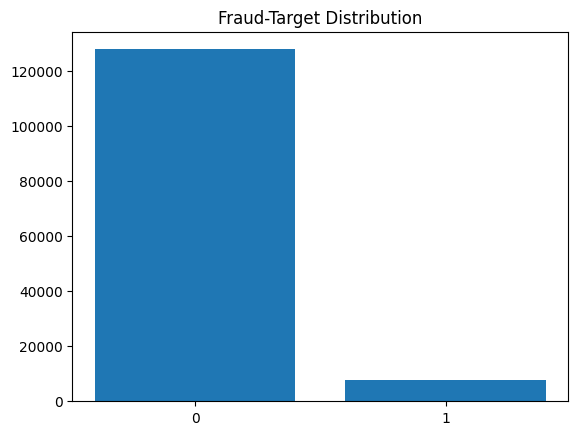

In [ ]:
import matplotlib.pyplot as plt

fraudactivities=client_train.groupby(['target'])['client_id'].count()
plt.bar(x=fraudactivities.index,height=fraudactivities.values,tick_label=[0,1])
plt.title('Fraud-Target Distribution')
plt.show()

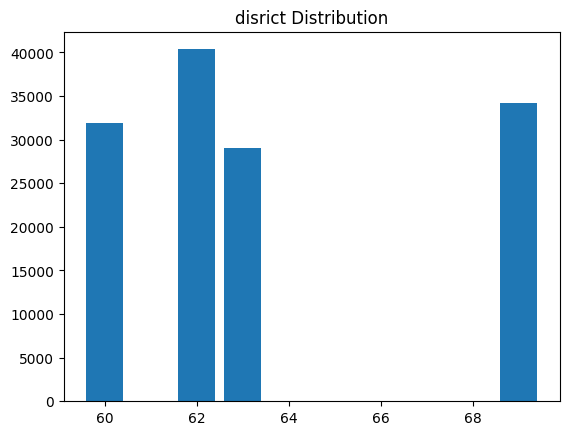

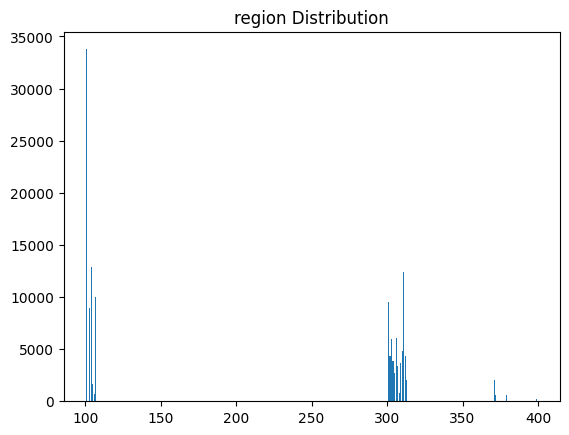

In [ ]:
for col in ['disrict','region']:
  region=client_train.groupby([col])['client_id'].count()
  plt.bar(x=region.index,height=region.values)
  plt.title(col+" Distribution")
  plt.show()

In [ ]:
print("\n--Target class breakdown---")
print(client_train['target'].value_counts())

print("\n--Target class breakdown---")
print(client_train['target'].value_counts(normalize=True)*100)


--Target class breakdown---
target
0.0    127927
1.0      7566
Name: count, dtype: int64

--Target class breakdown---
target
0.0    94.415948
1.0     5.584052
Name: proportion, dtype: float64


This shows that the class is  heavily imbalanced which is normal

In [ ]:
import numpy as np

In [ ]:
invoice_train['consumption_total']=(
    invoice_train['consommation_level_1']+
    invoice_train['consommation_level_2']+
    invoice_train['consommation_level_3']+
    invoice_train['consommation_level_4']
)

invoice_train['index_diff']=invoice_train['new_index']-invoice_train['old_index']
invoice_train['is_zero_consumption']=(invoice_train['consumption_total']==0).astype(int)
invoice_train['is_negative_diff']=(invoice_train['index_diff']<0).astype(int)
invoice_train['index_mismatch']=np.abs(invoice_train['index_diff']-invoice_train['consumption_total'])


invoice_train=invoice_train.groupby('client_id').agg(
    total_invoices=('invoice_date','count'),
    mean_consumption=('consumption_total','mean'),
    max_consumption=('consumption_total','max'),
    min_consumption=('consumption_total','min'),
    std_consumption=('consumption_total','std'),
    sum_consumption=('consumption_total','sum'),

    zero_consumption=('is_zero_consumption','sum'),
    mean_level_1=('consommation_level_1','mean'),
    sum_level_1=('consommation_level_1','sum'),
    negative_diff_count=('is_negative_diff','sum'),
    total_negative_diff=('is_negative_diff','sum'),
    max_index_diff=('index_diff','max'),
    min_index_diff=('index_diff','min'),
    mean_index_diff=('index_diff','mean'),
    sum_months=('months_number','sum'),
    distinct_counters=('counter_number','nunique'),
    counter_type_count=('counter_type','nunique'),

).reset_index()

invoice_train['consumption_per_month']=(invoice_train['sum_consumption']/(invoice_train['sum_months']+1e-5))
invoice_train['negative_diff_ratio']=invoice_train['negative_diff_count']/invoice_train['total_invoices']


In [ ]:
invoice_train=pd.merge(client_train,invoice_train,on='client_id',how='left')
invoice_train['creation_date']=pd.to_datetime(invoice_train['creation_date'],dayfirst=True)
invoice_train['creation_year']=invoice_train['creation_date'].dt.year
invoice_train['creation_month']=invoice_train['creation_date'].dt.month
invoice_train['client_age_years']=2019-invoice_train['creation_year']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X=invoice_train.drop(columns=['client_id','creation_date','target'])
y=invoice_train['target']

X_tr,X_va,y_tr,y_va=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
!pip install Catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.0 MB/s eta 0:00:00


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

In [ ]:
from catboost import CatBoostClassifier

In [ ]:
cb=CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)
cb.fit(X_tr,y_tr,eval_set=(X_va,y_va),use_best_model=True,early_stopping_rounds=50)
cb_val_preds=cb.predict_proba(X_va)[:,1]
cb_score=roc_auc_score(y_va,cb_val_preds)
print(f"CB Score:{cb_score}")

0:	test: 0.6890866	best: 0.6890866 (0)	total: 77.2ms	remaining: 1m 17s
100:	test: 0.8293606	best: 0.8293606 (100)	total: 4.45s	remaining: 39.6s
200:	test: 0.8379933	best: 0.8379986 (199)	total: 10.5s	remaining: 41.6s
300:	test: 0.8411766	best: 0.8411766 (300)	total: 14.9s	remaining: 34.7s
400:	test: 0.8431578	best: 0.8431578 (400)	total: 18.5s	remaining: 27.6s
500:	test: 0.8439322	best: 0.8439437 (497)	total: 22s	remaining: 22s
600:	test: 0.8444371	best: 0.8444488 (554)	total: 27.8s	remaining: 18.5s
700:	test: 0.8449553	best: 0.8449608 (699)	total: 31.3s	remaining: 13.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.845058375
bestIteration = 721

Shrink model to first 722 iterations.
CB Score:0.8450583749818983


In [ ]:
invoice_test['consumption_total']=(
    invoice_test['consommation_level_1']+
    invoice_test['consommation_level_2']+
    invoice_test['consommation_level_3']+
    invoice_test['consommation_level_4']
)

invoice_test['index_diff']=invoice_test['new_index']-invoice_test['old_index']
invoice_test['is_zero_consumption']=(invoice_test['consumption_total']==0).astype(int)
invoice_test['is_negative_diff']=(invoice_test['index_diff']<0).astype(int)
invoice_test['index_mismatch']=np.abs(invoice_test['index_diff']-invoice_test['consumption_total'])


invoice_test=invoice_test.groupby('client_id').agg(
    total_invoices=('invoice_date','count'),
    mean_consumption=('consumption_total','mean'),
    max_consumption=('consumption_total','max'),
    min_consumption=('consumption_total','min'),
    std_consumption=('consumption_total','std'),
    sum_consumption=('consumption_total','sum'),

    zero_consumption=('is_zero_consumption','sum'),
    mean_level_1=('consommation_level_1','mean'),
    sum_level_1=('consommation_level_1','sum'),
    negative_diff_count=('is_negative_diff','sum'),
    total_negative_diff=('is_negative_diff','sum'),
    max_index_diff=('index_diff','max'),
    min_index_diff=('index_diff','min'),
    mean_index_diff=('index_diff','mean'),
    sum_months=('months_number','sum'),
    distinct_counters=('counter_number','nunique'),
    counter_type_count=('counter_type','nunique'),

).reset_index()

invoice_test['consumption_per_month']=(invoice_test['sum_consumption']/(invoice_test['sum_months']+1e-5))
invoice_test['negative_diff_ratio']=invoice_test['negative_diff_count']/invoice_test['total_invoices']


In [ ]:
invoice_test=pd.merge(client_test,invoice_test,on='client_id',how='left')
invoice_test['creation_date']=pd.to_datetime(invoice_test['creation_date'],dayfirst=True)
invoice_test['creation_year']=invoice_test['creation_date'].dt.year
invoice_test['creation_month']=invoice_test['creation_date'].dt.month
invoice_test['client_age_years']=2019-invoice_test['creation_year']

In [ ]:
X_test=invoice_test.drop(columns=['client_id','creation_date'])
cb_test=cb.predict_proba(X_test)[:,1]


In [ ]:
submission=pd.DataFrame({
    'client_id':invoice_test['client_id'],
    'target':cb_test
})
submission.to_csv('submission.csv_final',index=False)
print("Saved successfully!")
submission.head()

Saved successfully!


,client_id,target
0,test_Client_0,0.031585
1,test_Client_1,0.145803
2,test_Client_10,0.028845
3,test_Client_100,0.030017
4,test_Client_1000,0.094697
